In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Load datasets
calendar = pd.read_csv("../data/calendar_clean.csv")
sales = pd.read_csv("../data/sales_train_validation.csv")
weekly_sales = pd.read_csv("../data/weekly_sales.csv")
monthly_sales = pd.read_csv("../data/monthly_sales.csv")

print("Datasets loaded successfully!")
print("Calendar:", calendar.shape)
print("Sales:", sales.shape)
print("Weekly Sales:", weekly_sales.shape)
print("Monthly Sales:", monthly_sales.shape)

Datasets loaded successfully!
Calendar: (1969, 14)
Sales: (30490, 1919)
Weekly Sales: (825, 4)
Monthly Sales: (192, 4)


Store Sales Summary:
  store_id  total_sales
2     CA_3     11188180
0     CA_1      7698216
5     TX_2      7214384
8     WI_2      6544012
9     WI_3      6427782
6     TX_3      6089330
1     CA_2      5685475
4     TX_1      5595292
7     WI_1      5149062
3     CA_4      4103676


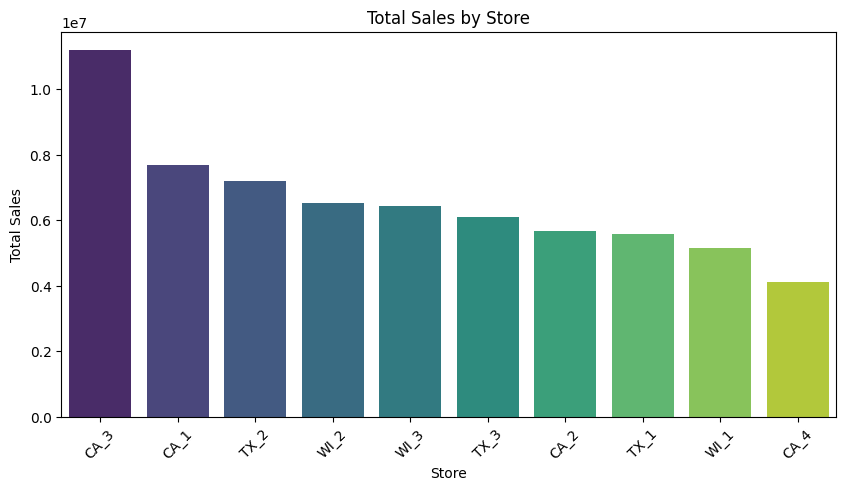

In [2]:
# Store Level Analysis
sales_cols = [col for col in sales.columns if col.startswith('d_')]

# Total sales per store
sales['total_sales'] = sales[sales_cols].sum(axis=1)

store_sales = sales.groupby('store_id')['total_sales'].sum().reset_index()
store_sales.columns = ['store_id', 'total_sales']
store_sales = store_sales.sort_values('total_sales', ascending=False)

print("Store Sales Summary:")
print(store_sales)

# Plot store sales
plt.figure(figsize=(10,5))
sns.barplot(x='store_id', y='total_sales', data=store_sales, palette='viridis')
plt.title("Total Sales by Store")
plt.xlabel("Store")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

Department Sales Summary:
       dept_id  total_sales
2      FOODS_3     32372076
5  HOUSEHOLD_1     11500526
1      FOODS_2      7629822
3    HOBBIES_1      5596460
0      FOODS_1      5088041
6  HOUSEHOLD_2      2980144
4    HOBBIES_2       528340


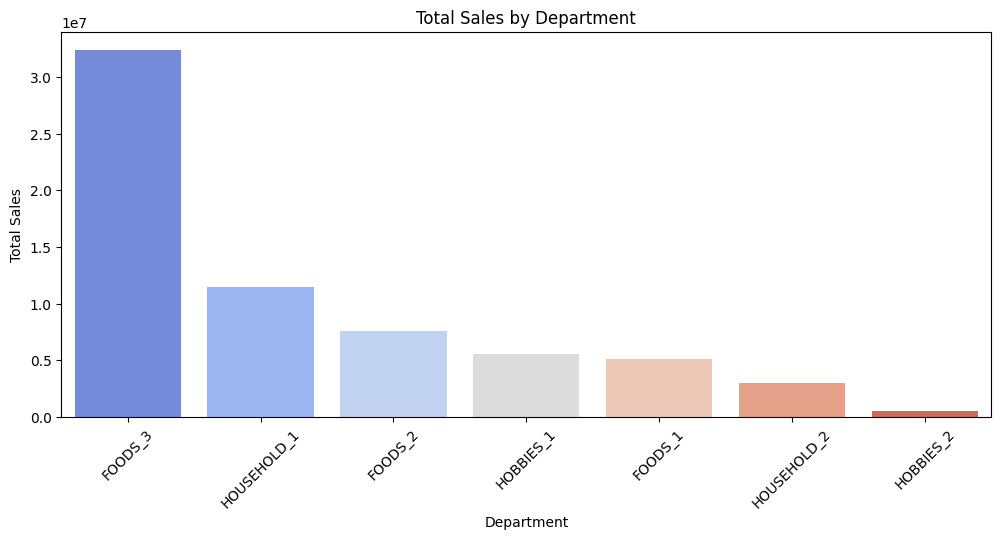


Category wise Department Sales:
      cat_id      dept_id  total_sales
0      FOODS      FOODS_1      5088041
1      FOODS      FOODS_2      7629822
2      FOODS      FOODS_3     32372076
3    HOBBIES    HOBBIES_1      5596460
4    HOBBIES    HOBBIES_2       528340
5  HOUSEHOLD  HOUSEHOLD_1     11500526
6  HOUSEHOLD  HOUSEHOLD_2      2980144


In [3]:
# Department Level Analysis
dept_sales = sales.groupby('dept_id')['total_sales'].sum().reset_index()
dept_sales = dept_sales.sort_values('total_sales', ascending=False)

print("Department Sales Summary:")
print(dept_sales)

# Plot department sales
plt.figure(figsize=(12,5))
sns.barplot(x='dept_id', y='total_sales', data=dept_sales, palette='coolwarm')
plt.title("Total Sales by Department")
plt.xlabel("Department")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

# Category wise department analysis
cat_dept = sales.groupby(['cat_id', 'dept_id'])['total_sales'].sum().reset_index()
print("\nCategory wise Department Sales:")
print(cat_dept)

State Sales Summary:
  state_id  total_sales
0       CA     28675547
1       TX     18899006
2       WI     18120856


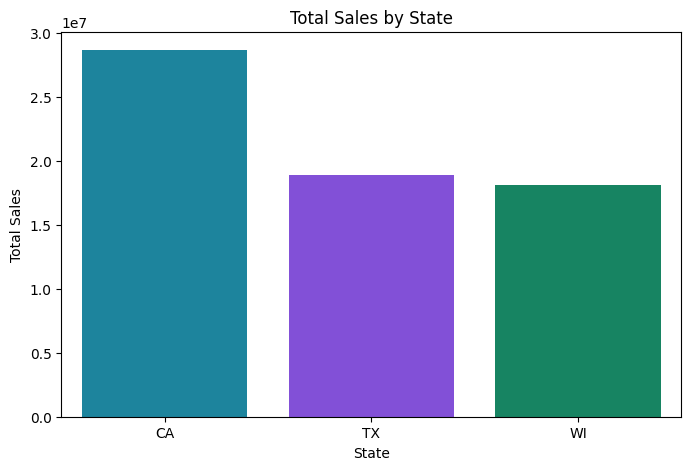


State wise Category Sales:
  state_id     cat_id  total_sales
0       CA      FOODS     19196302
1       CA    HOBBIES      3039883
2       CA  HOUSEHOLD      6439362
3       TX      FOODS     12956421
4       TX    HOBBIES      1592339
5       TX  HOUSEHOLD      4350246
6       WI      FOODS     12937216
7       WI    HOBBIES      1492578
8       WI  HOUSEHOLD      3691062


In [4]:
# State Level Analysis
state_sales = sales.groupby('state_id')['total_sales'].sum().reset_index()
state_sales = state_sales.sort_values('total_sales', ascending=False)

print("State Sales Summary:")
print(state_sales)

# Plot state sales
plt.figure(figsize=(8,5))
sns.barplot(x='state_id', y='total_sales', data=state_sales,
            palette=['#0891B2', '#7C3AED', '#059669'])
plt.title("Total Sales by State")
plt.xlabel("State")
plt.ylabel("Total Sales")
plt.show()

# State category analysis
state_cat = sales.groupby(['state_id', 'cat_id'])['total_sales'].sum().reset_index()
print("\nState wise Category Sales:")
print(state_cat)

In [5]:
# Save state and department analysis
state_cat.to_csv("../data/state_category_sales.csv", index=False)
dept_sales.to_csv("../data/department_sales.csv", index=False)

print("Analysis saved!")

print("\n" + "="*50)
print("WEEK 2 DAY 2 SUMMARY")
print("="*50)
print("Store Analysis Complete")
print("Top Store: CA_3 with 11,188,180 sales")
print("\nDepartment Analysis Complete")
print("Top Department: FOODS_3 with 32,372,076 sales")
print("\nState Analysis Complete")
print("Top State: CA with 28,675,547 sales")
print("\nFOODS dominates in all states!")
print("="*50)

Analysis saved!

WEEK 2 DAY 2 SUMMARY
Store Analysis Complete
Top Store: CA_3 with 11,188,180 sales

Department Analysis Complete
Top Department: FOODS_3 with 32,372,076 sales

State Analysis Complete
Top State: CA with 28,675,547 sales

FOODS dominates in all states!
